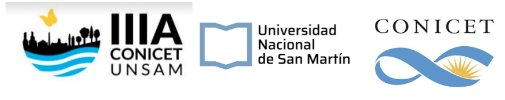  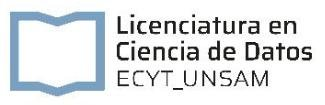

---

# NB03 — Datos vectoriales y vulnerabilidad social

Lo que veremos en esta notebook:

- [x] Datos vectoriales: puntos, líneas, polígonos, y la noción de escala
- [x] GeoPandas: GeoSeries, GeoDataFrame, CRS, operaciones geométricas
- [x] El Censo Nacional 2022: variables, tablas y unidades de análisis
- [x] Joins tabulares y validación de integridad referencial
- [x] Mapas coropléticos: esquemas de clasificación con `mapclassify`
- [x] Construcción de variables compuestas de vulnerabilidad
- [x] Agregación espacial y una primera mirada al MAUP
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Manipular datos vectoriales con GeoPandas con fluidez (lectura, reproyección, filtrado, joins, exportación).
- Construir un GeoDataFrame integrando geometrías del Censo 2022 con variables tabulares, con control de calidad del join.
- Diseñar un mapa coroplético eligiendo el esquema de clasificación apropiado según la distribución del dato.
- Construir un índice compuesto de vulnerabilidad a partir de variables censales, discutiendo sus limitaciones.
- Reconocer el problema de la unidad de área modificable (MAUP).

### Datos con los que trabajaremos

- `data/raw_data/vectorial/radios_censo_2022.gpkg` — radios censales del Censo 2022 para el área de estudio, con geometría poligonal. Fuente: CONICET (https://ri.conicet.gov.ar/handle/11336/238198).
- `data/raw_data/tablas/Indicadores de hogares. Radios, 2022.csv` — variables de hogar agregadas por radio: NBI, hacinamiento, materiales de vivienda, servicios. Fuente: poblaciones.org (https://poblaciones.org/catalogo).
- `data/raw_data/tablas/Indicadores de personas. Radios, 2022.csv` — variables de población por radio: grupos etarios, cobertura de salud, educación.

### Conexión con el arco del curso

En la clase anterior generamos productos raster (NDVI, NDWI) sobre el territorio. Ahora cambiamos de modelo de datos: pasamos del raster —una grilla regular de píxeles— al vectorial —geometrías vectoriales con atributos—. Esta clase construye el GeoDataFrame `radios_vulnerabilidad.gpkg` que va a ser insumo central de las notebooks siguientes cuando crucemos rasters con datos vectoriales, cuando analicemos la estructura espacial de la vulnerabilidad y cuando realicemos modelos de regresión espacial.

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import mapclassify

RAW  = 'data/raw_data/'
PROC = 'data/proc/'
OUT  = 'data/out/'

PROV_BA = '06'   # Buenos Aires province

# Códigos DEPTO verificados directamente desde el GeoPackage
PARTIDOS_DEPTO = [
    '364',  # General Rodríguez
    '371',  # General San Martín  (UNSAM)
    '408',  # Ituzaingó
    '410',  # Hurlingham
    '412',  # José C. Paz
    '525',  # Marcos Paz
    '539',  # Merlo
    '560',  # Moreno
    '568',  # Morón
    '756',  # San Isidro
    '760',  # San Miguel
    '840',  # Tres de Febrero
    '861',  # Vicente López
]

---
# 1. El modelo de datos vectorial

## 1.1 Puntos, líneas y polígonos

Mientras un raster representa el territorio como una grilla regular de celdas con un valor por celda, el modelo vectorial representa **objetos discretos** con geometría explícita y atributos asociados:

- **Punto** — una localización: una estación meteorológica, un asentamiento muestreado.
- **Línea** — una sucesión ordenada de puntos: un río, una ruta, un tendido de infraestructura.
- **Polígono** — un área cerrada: un radio censal, un partido, un cuerpo de agua.

Cada objeto lleva adjunta una fila de atributos en una tabla. La tabla es un DataFrame común; la novedad es que una columna —llamada `geometry`— contiene geometrías de Shapely.

## 1.2 La noción de escala en vectores

A diferencia del raster, el vectorial no tiene resolución en píxeles: los polígonos tienen bordes exactos. Pero la **escala de captura** determina el nivel de detalle de esas geometrías. Un mapa de radios censales digitalizado a 1:5000 tiene bordes mucho más precisos que uno a 1:50000. Mezclar datos de escalas distintas puede producir *sliver polygons* (polígonos-astilla) en los bordes.

## 1.3 Formatos vectoriales: una breve comparación

| Formato | Estructura | Estándar | Cuándo usarlo |
|---|---|---|---|
| **Shapefile** (`.shp` + 4 aux) | Multi-archivo ESRI | De facto (no abierto) | Compatibilidad con software heredado |
| **GeoJSON** (`.geojson`) | Texto JSON | Abierto (IETF RFC 7946) | Intercambio web, datos pequeños |
| **GeoPackage** (`.gpkg`) | SQLite con extensión geoespacial | **Abierto (OGC)** | Trabajo de producción |

**GeoPackage merece una mención especial.** Es el formato recomendado por el OGC (*Open Geospatial Consortium*) como sucesor moderno del Shapefile. Sus ventajas concretas son: un único archivo portátil, soporte de múltiples capas (vectores y rasters en el mismo archivo), nombres de columnas sin límite de caracteres (el Shapefile solo permite 10), soporte completo de Unicode, sin límite de 2 GB, y transacciones ACID. En este curso lo usamos para todos los archivos de trabajo.

---
# 2. GeoPandas en acción

## 2.1 Lectura y filtrado del GeoPackage censal

In [ ]:
# El GeoPackage de CONICET contiene todos los radios de Argentina (~52000).
# Lo filtramos a los partidos de nuestra área de estudio.
gdf_todo = gpd.read_file(RAW + 'vectorial/radios_censo_2022.gpkg')

print(f'Radios en Argentina (GeoPackage completo): {len(gdf_todo)}')
print(f'CRS                                       : {gdf_todo.crs}')
print(f'Tipo de geometría                         : {gdf_todo.geom_type.unique()}')
print(f'Columnas                                  : {list(gdf_todo.columns)}')

### 2.1.a Descubrimiento: ¿qué partidos hay en el GeoPackage?

Antes de filtrar es buena práctica inspeccionar qué valores exactos tiene la columna `NOMDEPTO`. Es la única forma de saber si el dato usa tildes, abreviaciones o mayúsculas distintas a lo esperado — errores de este tipo hacen fallar los filtros silenciosamente.

In [ ]:
# Listamos todos los partidos de Buenos Aires para verificar nombres y códigos
ba_partidos = (gdf_todo[gdf_todo['PROV'] == PROV_BA]
               .groupby(['DEPTO', 'NOMDEPTO'])
               .size()
               .rename('n_radios')
               .reset_index()
               .sort_values('NOMDEPTO'))

# Buscamos los cuatro que nos interesan
for termino in ['moreno', 'merlo', 'rodriguez', 'marcos paz',
               'martin', 'ituzaingo', 'hurlingham', 'moron',
               'isidro', 'febrero', 'lopez','c. paz']:
    mask = ba_partidos['NOMDEPTO'].str.lower().str.contains(termino)
    print(ba_partidos[mask][['DEPTO','NOMDEPTO','n_radios']].to_string(index=False))
print()
print('Códigos verificados → PARTIDOS_DEPTO =', PARTIDOS_DEPTO)

In [ ]:
# Filtramos los partidos del corredor AMBA norte-oeste con los códigos verificados
gdf_radios = gdf_todo[
    (gdf_todo['PROV'] == PROV_BA) &
    (gdf_todo['DEPTO'].isin(PARTIDOS_DEPTO))
].copy()

resumen = (gdf_radios.groupby(['DEPTO','NOMDEPTO'])
           .size().rename('n_radios').reset_index())
print(f'Radios en el área de estudio: {len(gdf_radios)}')
print()
print(resumen.to_string(index=False))
print()
if len(resumen) < len(PARTIDOS_DEPTO):
    faltantes = set(PARTIDOS_DEPTO) - set(resumen['DEPTO'])
    print(f'ATENCIÓN: {len(faltantes)} código(s) sin match → {faltantes}')
else:
    print('✓ Los partidos del noroeste fueron encontrados correctamente.')

## 2.2 El código del radio censal (LINK)

En este GeoPackage la columna de identificación única del radio es **`LINK`**. Su estructura sigue la jerarquía del INDEC:

```
06  539  01  01
├── Provincia (06 = Buenos Aires)
    ├── Partido / Departamento (539 = Moreno)
        ├── Fracción censal (01)
            └── Radio censal (01)
```

Total: **9 dígitos** (2+3+2+2). Es un string — nunca un entero. Si se castea a `int` los ceros iniciales desaparecen y los joins fallan silenciosamente.

> **Nota Censo 2022.** Algunas capas publicadas directamente por el INDEC agregan dígitos extra de tipo de radio (urbano/rural) o nivel de gobierno local, dando 11 o 13 caracteres. Este GeoPackage usa el formato canónico de 9 dígitos. Siempre verificá la longitud antes de hacer un join.

In [ ]:
# Verificamos el formato del LINK
print('Tipo de dato :', gdf_radios['LINK'].dtype)
print('Longitudes únicas:', gdf_radios['LINK'].str.len().unique())
print('Ejemplo          :', gdf_radios['LINK'].iloc[0])
print()
# Ningún código nulo
print(f'Valores nulos en LINK: {gdf_radios["LINK"].isna().sum()}')

## 2.3 Reproyección

In [ ]:
# Los datos INDEC vienen en WGS84 (EPSG:4326) — grados decimales.
# Para calcular áreas y cruzar con imágenes Sentinel-2 reproyectamos a UTM 21S.
gdf_radios = gdf_radios.to_crs('EPSG:32721')

# Área en hectáreas desde la geometría proyectada
gdf_radios['area_ha'] = gdf_radios.geometry.area / 10_000

print(f'CRS después de reproyectar: {gdf_radios.crs}')
print(f'Área total del área de estudio: {gdf_radios.area_ha.sum():,.0f} ha')
print(f'Área mediana por radio        : {gdf_radios.area_ha.median():.2f} ha')
print(f'Rango                         : [{gdf_radios.area_ha.min():.2f}, {gdf_radios.area_ha.max():.0f}] ha')

La distribución de áreas es muy asimétrica. El INDEC diseñó los radios para tener una **cantidad similar de hogares** (~300), no un área similar. En zonas densas los radios son muy pequeños; en periurbano y rural pueden ser enormes. Esta variabilidad tiene consecuencias directas cuando hacemos mapas coropléticos y es la causa del MAUP (sección 7).

---
# 3. Unión con las tablas del Censo 2022

Los datos del Censo 2022 llegan separados: la geometría por un lado y las tablas estadísticas por otro. Las tablas de `poblaciones.org` tienen una columna de clave llamada `"Código de radio."` (con punto al final — así viene el nombre en el CSV). La clave coincide con `LINK` en el GeoPackage: ambas son el código INDEC de 9 dígitos.

**Estrategia para las columnas duplicadas.** El CSV de hogares repite algunas columnas al final (por ejemplo `"Total de hogares"` aparece dos veces: una como primera columna de la tabla y otra en el bloque de totales geográficos al final). Al leer con pandas el segundo nombre queda como `"Total de hogares.1"`. Trabajamos siempre con la primera ocurrencia.

In [ ]:
# ── Lectura del CSV de hogares ────────────────────────────────────────────────
# Especificamos dtype en la clave para preservar ceros iniciales
tab_hog = pd.read_csv(
    RAW + 'tablas/Indicadores de hogares. Radios, 2022.csv',
    dtype={'Código de radio.': str}
)

print(f'Filas: {len(tab_hog)},  columnas: {tab_hog.shape[1]}')
print()
print('Primeras 5 columnas:')
for c in tab_hog.columns[:5]:
    print(f'  {repr(c)}')
print('...')
print('Últimas 5 columnas:')
for c in tab_hog.columns[-5:]:
    print(f'  {repr(c)}')

In [ ]:
# ── Selección y renombre de columnas relevantes ───────────────────────────────
# Trabajamos solo con lo que vamos a usar para no cargar columnas innecesarias.
# "Total de hogares" aparece dos veces en el CSV; pandas renombra la segunda a
# "Total de hogares.1". Usamos la primera ocurrencia (columna índice 1).

COLS_HOG = {
    'Código de radio.'                                                    : 'cod_radio',
    'Total de hogares'                                                    : 'hogares_total',
    'Hogares con al menos un indicador NBI'                               : 'hogares_nbi',
    'Hogares con hacinamiento (más de 2 personas por cuarto)'             : 'hogares_hacinados',
    'Hogares con hacinamiento crítico (más de 3 personas por cuarto)'     : 'hacinamiento_critico',
    'Hogares sin cobertura de techo tipo 1 (Membrana, baldosa, losa o teja)': 'sin_techo_tipo1',
    'Hogares sin piso tipo 1 (cerámica, baldosa, mosaico, mármol, madera, alfombrado)': 'sin_piso_tipo1',
    'Hogares sin cloaca'                                                  : 'sin_cloaca',
    'Hogares sin agua para beber y cocinar proveniente de red pública'    : 'sin_agua_red',
    'Población total'                                                     : 'poblacion_total',
    'Superficie en km2'                                                   : 'area_km2_csv',
}

# Verificamos que todas las columnas estén presentes
faltantes = [c for c in COLS_HOG if c not in tab_hog.columns]
if faltantes:
    print('ATENCIÓN — columnas no encontradas en el CSV:')
    for c in faltantes:
        print(f'  {repr(c)}')
else:
    print('Todas las columnas encontradas ✓')

tab = tab_hog[list(COLS_HOG.keys())].rename(columns=COLS_HOG).copy()

# La clave de join también debe ser string de 9 chars
tab['cod_radio'] = tab['cod_radio'].str.zfill(9)
print(f'\nFilas en la tabla: {len(tab)}')
print(tab[['cod_radio','hogares_total','hogares_nbi','poblacion_total']].head(3))

## 3.1 `merge` con validación

`pandas.merge` tiene un argumento `validate` que chequea la cardinalidad del join y lanza error si no se cumple. Para cruzar geometrías con tabla del censo esperamos **1:1**: cada radio tiene exactamente una geometría y una fila de datos.

In [ ]:
# Creamos cod_radio en el GeoDataFrame a partir de LINK
gdf_radios['cod_radio'] = gdf_radios['LINK'].str.zfill(9)

gdf = gdf_radios.merge(
    tab,
    on='cod_radio',
    how='left',
    validate='1:1'
)

# Control: cuántos radios no matchearon
sin_datos = gdf['hogares_total'].isna().sum()
print(f'Radios con datos censales : {(~gdf.hogares_total.isna()).sum()}')
print(f'Radios sin datos (NaN)    : {sin_datos}')
if sin_datos > 0:
    print('Radios sin datos:')
    print(gdf.loc[gdf.hogares_total.isna(), 'cod_radio'].values)

In [ ]:
# ── Columnas jerárquicas: fracción y partido ──────────────────────────────────
# Las creamos acá, justo después del merge, para que estén disponibles
# en el resto de la notebook (mapas, MAUP, guardado).
gdf['cod_fraccion'] = gdf['cod_radio'].str[:7]   # prov(2)+depto(3)+frac(2)
gdf['cod_partido']  = gdf['cod_radio'].str[:5]   # prov(2)+depto(3)

print('Columnas jerárquicas creadas:')
print(f'  cod_fraccion — {gdf.cod_fraccion.nunique()} fracciones únicas')
print(f'  cod_partido  — {gdf.cod_partido.nunique()} partidos únicos')
print()
print(gdf[['cod_radio','cod_fraccion','cod_partido','NOMDEPTO']].head(3))

### ¿Qué hacer si `validate='1:1'` falla?

**Duplicados en el GeoDataFrame**: `gdf_radios['cod_radio'].duplicated().sum()` los detecta. Puede haber radios multipart mal digitalizados o radios especiales (áreas no habitadas sin datos tabulares).

**Códigos distintos**: el caso más frecuente es que un lado tenga 9 dígitos y el otro 11 o 13. Siempre verificar con `.str.len().value_counts()` antes de intentar el join y normalizar con `.str.zfill(9)` o `.str[-9:]` según corresponda.

---
# 4. Construcción de variables de vulnerabilidad

A partir de las tablas del Censo 2022 construimos variables que van a acompañarnos a lo largo del curso:

- **NBI (%)**: proporción de hogares con al menos una Necesidad Básica Insatisfecha.
- **Vivienda precaria (%)**: proporción de hogares con déficit de materiales de construcción.
- **Hacinamiento (%)**: proporción de hogares con más de 2 personas por cuarto.
- **Densidad poblacional**: habitantes por hectárea.

**Variables intensivas vs extensivas.** Los mapas coropléticos exigen **variables intensivas** (porcentajes, densidades, razones): el color de un polígono se compara visualmente con los de sus vecinos, y un *conteo* es influenciado por el tamaño del polígono. Un radio con 200 hogares con NBI en 1 ha es muy distinto a un radio con los mismos 200 hogares en 100 ha. El porcentaje normaliza esa diferencia.

**Nota sobre "vivienda precaria"**. El Censo 2022 no tiene una única variable que defina "precariedad". Construimos un proxy usando dos indicadores materiales: `sin_techo_tipo1` (sin membrana, baldosa, losa ni teja) y `sin_piso_tipo1` (sin cerámica, madera ni alfombra). Un hogar tiene déficit material si carece de los dos. En la sección 6 discutimos la relación entre esta definición y el NBI.

In [ ]:
# Variables básicas
gdf['nbi_pct']         = 100 * gdf['hogares_nbi']        / gdf['hogares_total']
gdf['hacinamiento_pct']= 100 * gdf['hogares_hacinados']  / gdf['hogares_total']

# Vivienda precaria: sin techo Y sin piso tipo 1
# (estimación conservadora; el máximo posible es max(sin_techo, sin_piso))
# Usamos max como límite superior (bound), no como estimación puntual
gdf['viv_precaria_pct'] = 100 * gdf[['sin_techo_tipo1','sin_piso_tipo1']].max(axis=1)                                 / gdf['hogares_total']

# Densidad poblacional
# Usamos area_ha calculada desde la geometría (UTM 21S) — más confiable que el CSV
gdf['densidad_pob'] = gdf['poblacion_total'] / gdf['area_ha']

print(gdf[['nbi_pct','viv_precaria_pct','hacinamiento_pct','densidad_pob']]      .describe().round(2))

In [ ]:
# Sanity checks básicos
for col in ['nbi_pct','viv_precaria_pct','hacinamiento_pct']:
    fuera_rango = ((gdf[col] < 0) | (gdf[col] > 100)).sum()
    nans = gdf[col].isna().sum()
    print(f'{col:25s} — NaN: {nans:3d}   fuera de [0,100]: {fuera_rango}')

print(f'{"densidad_pob":25s} — NaN: {gdf.densidad_pob.isna().sum():3d}   '
      f'media: {gdf.densidad_pob.mean():.1f} hab/ha')

---
# 5. Mapas coropléticos y esquemas de clasificación

Un **mapa coroplético** pinta cada polígono con un color según el valor de una variable. Dos decisiones son críticas:

1. **Los cortes de clase**: en cuántos intervalos dividimos la variable y dónde ponemos los cortes.
2. **La paleta**: secuencial (de menos a más), divergente (dos direcciones desde un valor central), o cualitativa (categorías sin orden).

La biblioteca `mapclassify` implementa los esquemas estándar:

| Esquema | Cómo elige los cortes | Cuándo usarlo |
|---|---|---|
| `'equal_interval'` | Divide el rango en $k$ partes iguales | Distribución uniforme |
| `'quantiles'` | Cada clase tiene aprox. el mismo nº de polígonos | Maximiza el contraste visual |
| `'natural_breaks'` (Fisher-Jenks) | Minimiza varianza intra-clase | Distribuciones asimétricas con clusters |
| `'user_defined'` | Cortes definidos explícitamente por el analista | Umbrales con significado sustantivo |
| `'headtail_breaks'` | Recursivo para colas largas | Datos tipo ley de potencia |

Referencia: Brewer (2003) *ColorBrewer*; Rey, Anselin & Kang (2023) *Geographic Data Science with Python*.

## 5.1 El territorio: un primer mapa de referencia

Antes de comparar esquemas de clasificación, construimos un mapa de referencia que responda la pregunta más básica: **¿dónde estamos?** Este mapa va a servir de ancla visual para todo el curso.

In [ ]:
# ── Partidos: disolvemos los radios por cod_partido ──────────────────────────
gdf_partidos = gdf.dissolve(
    by='cod_partido',
    aggfunc={'NOMDEPTO': 'first', 'hogares_nbi': 'sum', 'hogares_total': 'sum'}
)
gdf_partidos['nbi_pct'] = 100 * gdf_partidos['hogares_nbi'] / gdf_partidos['hogares_total']

# ── Figura de referencia ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10), facecolor='white')
ax.set_facecolor('#f5f5f5')

# Radios con natural_breaks y OrRd (empieza con naranja claro, evita el amarillo blancuzco)
gdf.plot(column='nbi_pct', cmap='OrRd', scheme='natural_breaks', k=5,
         edgecolor='none', linewidth=0, alpha=0.85, legend=True,
         legend_kwds={'title': 'NBI %', 'fmt': '{:.0f}%',
                      'loc': 'lower right', 'fontsize': 9},
         ax=ax)

# Contornos de partido encima para dar estructura geográfica
gdf_partidos.boundary.plot(ax=ax, color='#333333', linewidth=1.4)

# Etiquetas de partido
for idx, row in gdf_partidos.iterrows():
    rp = row.geometry.representative_point()
    cx, cy = rp.x, rp.y
    nombre = row['NOMDEPTO'].title()   # "MORENO" → "Moreno"
    ax.text(cx, cy, nombre, ha='center', va='center', fontsize=10,
            fontweight='bold', color='#222222',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75,
                      edgecolor='none'))

ax.set_title('NBI % por radio censal — Natural breaks (k=5)\n'
             'AMBA norte-oeste — 11 partidos  (Censo 2022)',
             fontsize=12, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT + 'mapa_nbi_referencia.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Guardado: mapa_nbi_referencia.png')

Con este mapa ya podemos orientarnos: los contornos negros delimitan los cuatro partidos; los radios coloreados muestran la heterogeneidad interna de cada uno. Natural breaks elige los cortes para maximizar la diferencia visual entre clases, lo que lo hace apropiado para distribuciones asimétricas como el NBI en zonas periurbanas.

## 5.2 Efecto del esquema de clasificación

In [ ]:
# Histograma de NBI para entender la distribución antes de elegir el esquema
fig, ax = plt.subplots(figsize=(9, 4), facecolor='white')
ax.hist(gdf['nbi_pct'].dropna(), bins=40, color='#c04040', edgecolor='white',
        linewidth=0.3, alpha=0.85)
ax.axvline(gdf['nbi_pct'].mean(),  color='#333', ls='--', lw=1.5,
           label=f'Media  = {gdf.nbi_pct.mean():.1f}%')
ax.axvline(gdf['nbi_pct'].median(), color='#333', ls=':',  lw=1.5,
           label=f'Mediana = {gdf.nbi_pct.median():.1f}%')
ax.set_xlabel('NBI %'); ax.set_ylabel('Radios')
ax.set_title('Distribución del NBI % por radio')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Asimetría (skewness): {gdf.nbi_pct.skew():.2f}')
print('Distribución muy asimétrica → intervalos iguales desperdician color;')
print('natural_breaks o user_defined con cortes sustantivos son más informativos.')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.set_facecolor('white')
for ax in axes.ravel():
    ax.set_facecolor('#f5f5f5')

esquemas = [
    ('equal_interval', 5, 'Intervalos iguales (k=5)'),
    ('quantiles',      5, 'Cuantiles (k=5)'),
    ('natural_breaks', 5, 'Natural breaks / Fisher-Jenks (k=5)'),
    ('user_defined', None, 'Clases fijas de 20 pp (0-20, 20-40, ...)'),
]

for ax, (scheme, k, titulo) in zip(axes.ravel(), esquemas):
    kwargs = dict(column='nbi_pct', cmap='OrRd', scheme=scheme,
                  edgecolor='none', linewidth=0, alpha=0.85, legend=True,
                  missing_kwds={'color': '#cccccc', 'label': 'sin dato'},
                  legend_kwds={'title': 'NBI %', 'fmt': '{:.0f}%',
                               'loc': 'lower right', 'fontsize': 8},
                  ax=ax)
    if k is not None:
        kwargs['k'] = k
    # user_defined necesita bins explícitos declarados por el analista
    if scheme == 'user_defined':
        kwargs['classification_kwds'] = {'bins': [20, 40, 60, 80, 100]}
    gdf.plot(**kwargs)
    # Contornos de partido en todos los paneles
    gdf_partidos.boundary.plot(ax=ax, color='#444444', linewidth=0.9)
    ax.set_title(titulo, fontsize=9.5, pad=5)
    ax.set_axis_off()

plt.suptitle('Efecto del esquema de clasificación — NBI % por radio censal\n'
             'AMBA norte-oeste — 11 partidos  (Censo 2022)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT + 'mapa_comparacion_esquemas.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: mapa_comparacion_esquemas.png')

**Qué observar en esta comparación.**

Los cuatro mapas muestran exactamente los mismos datos pero cuentan historias visuales distintas:

- **Intervalos iguales**: el rango es 0%–59%, así que cada intervalo cubre ~12 puntos. Como la mayoría de los radios tiene NBI bajo, casi todos caen en los primeros dos colores. El color rojo oscuro aparece en muy pocos radios — que sí son los más vulnerables, pero la imagen en general es muy pálida y poco informativa para el grueso del territorio.

- **Cuantiles**: reparte los radios en grupos de igual tamaño, maximizando el contraste visual. El costo: una diferencia de 1 punto de NBI puede separar dos radios en clases distintas si cae justo en el corte. Puede hacer que diferencias pequeñas parezcan estructurales.

- **Natural breaks (Fisher-Jenks)**: busca cortes donde hay "saltos naturales" en la distribución, minimizando la varianza intra-clase. Es el balance habitual para datos asimétricos como el NBI y el esquema de referencia de este curso.

- **Clases fijas de 20 puntos**: los cortes son 0, 20, 40, 60, 80 y 100% — valores "redondos" con significado directo en el dominio del NBI, independientes de la distribución de los datos. La mayoría de los radios cae en los primeros dos colores (NBI 0-20% y 20-40%), lo que muestra con claridad que en el grueso del territorio la vulnerabilidad es baja o media-baja. La diferencia con intervalos iguales es conceptual: los cortes son los mismos pero acá son elegidos por el analista con criterio sustantivo ("sobre 40% de NBI es una zona de atención prioritaria"), no por aritmética sobre el rango del dato.

**Regla para este curso:** `natural_breaks` como opción por defecto. `user_defined` con cortes sustantivos cuando se quiera comunicar a no-especialistas o fijar umbrales de política ("NBI > 40% = zona prioritaria"). `quantiles` cuando se quiera maximizar el contraste visual.

### Ejercicio guiado 5.1

Hacé un mapa coroplético de `hacinamiento_pct` con `natural_breaks` y 5 clases, con los contornos de partido encima. ¿Las zonas de concentración coinciden con las del NBI? ¿Qué partes del territorio se destacan en una variable pero no en la otra?

In [ ]:
# Tu código acá


---
# 6. Un índice compuesto de vulnerabilidad

En vez de mirar una variable a la vez, combinamos las tres en un **índice compuesto**. La estrategia más simple es estandarizar cada variable (restar la media, dividir por el desvío) y promediar los z-scores. La estandarización normaliza las unidades: NBI (%) y densidad (hab/ha) están en escalas completamente distintas, pero después de estandarizar son comparables.

**¿Por qué no usar directamente el NBI?** El NBI captura varias dimensiones de carencia —habitacional, sanitaria, educativa— pero es una variable binaria por hogar (con/sin NBI). Nuestro índice agrega dimensiones que el NBI no captura directamente, como la densidad (que determina la exposición colectiva a riesgos ambientales).

In [ ]:
cols_vuln = ['nbi_pct', 'viv_precaria_pct', 'hacinamiento_pct']

for c in cols_vuln:
    media = gdf[c].mean()
    std   = gdf[c].std()
    gdf[c + '_z'] = (gdf[c] - media) / std

gdf['iv'] = gdf[[c + '_z' for c in cols_vuln]].mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 10))
gdf.plot(column='iv', cmap='RdYlBu_r', legend=True, scheme='quantiles', k=5,
         edgecolor='none', linewidth=0, alpha=0.85,
         legend_kwds={'title': 'Índice de Vulnerabilidad (z-score promedio)',
                      'fmt': '{:.2f}', 'loc':'lower right'},
         ax=ax)
ax.set_title('Índice compuesto de vulnerabilidad por radio censal\n'
             'AMBA norte-oeste — Censo 2022', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Correlación entre las tres variables

In [ ]:
# Matriz de correlación
corr = gdf[cols_vuln].corr().round(3)
print('Matriz de correlación (Pearson):')
print(corr)
print()
print('Interpretación: correlaciones altas entre variables redundantes reducen la')
print('información que agrega el promedio de z-scores. Si rho ≈ 1, las tres variables')
print('cuentan esencialmente la misma historia.')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
pares = [('nbi_pct','hacinamiento_pct'), ('nbi_pct','viv_precaria_pct'),
         ('hacinamiento_pct','viv_precaria_pct')]
for ax, (x, y) in zip(axes, pares):
    ax.scatter(gdf[x], gdf[y], alpha=0.25, s=8, color='steelblue')
    ax.set_xlabel(x); ax.set_ylabel(y)
    r = gdf[[x,y]].corr().iloc[0,1]
    ax.set_title(f'r = {r:.2f}')
    ax.grid(alpha=0.3)
plt.suptitle('Correlaciones entre variables de vulnerabilidad')
plt.tight_layout()
plt.show()

**Una observación sobre redundancia.** Si las tres variables estuvieran perfectamente correlacionadas ($\rho = 1$), promediar sus z-scores daría lo mismo que usar cualquiera de las tres por separado: los términos extra no agregan información. En nuestro caso las correlaciones son altas (orden 0.6–0.9). El índice agrega información respecto a la variable dominante (NBI) pero menos de lo que sugiere "son tres variables". Esta es una limitación conocida del promedio de z-scores y una de las razones por las que índices más elaborados —como el IVS de Rosati, Olego & Vazquez Brust— usan PCA o autoencoders.

---
# 6.bis Un paréntesis metodológico: el IVS de Rosati, Olego & Vazquez Brust (2019)

El índice que acabamos de construir es una versión deliberadamente simple. En la literatura argentina hay un ejemplo más sofisticado del mismo ejercicio, hecho entre otros por un investigador de nuestra universidad: el **Índice de Vulnerabilidad Sanitaria (IVS)** de Germán Rosati (CONICET, UNSAM), Tomás Olego y Antonio Vazquez Brust.

Las decisiones técnicas que distinguen el IVS del promedio de z-scores:

| Paso | Versión simple (lo que hicimos) | Versión IVS |
|---|---|---|
| Codificación de variables ordinales | Numéricas directas | *Thermometer encoding* |
| Reducción de dimensión | Z-score promedio | **Autoencoder** (NN) para SES + tiempo de viaje a centro de salud por OSRM |
| Linealización de distribuciones | — | **Rankit** $z = \Phi^{-1}\!\left((r - 0.5)/n\right)$ |
| Combinación de dimensiones | Media simple | **PCA semiparamétrico** sobre correlación de Spearman (Han & Liu 2014) |
| Agregación a radio | Promedio | **Trimean de Tukey** $\frac{1}{4}Q_{0.25} + \frac{1}{2}Q_{0.5} + \frac{1}{4}Q_{0.75}$ |

Cada capa del procedimiento resuelve un problema distinto: el rankit neutraliza asimetrías y multimodalidades que harían inestable al PCA clásico; el trimean es más robusto que la media y más eficiente que la mediana; el autoencoder extrae una representación no-lineal del SES. El paper valida el IVS prediciendo la proporción de población sin cobertura médica a nivel departamento con correlación Pearson de 0.70.

**¿Por qué traerlo ahora?** Hace explícito que lo que estamos construyendo es el mismo objeto metodológico que se usa en investigación. Además usa dos infraestructuras que vamos a reencontrar: **OSM + OSRM** para accesibilidad (en el análisis de procesos de puntos) y una lógica de **regresión espacial para validar** (en las notebooks finales del curso).

---
# 7. El problema de la unidad de área modificable (MAUP)

El **MAUP** (*Modifiable Areal Unit Problem*, Openshaw & Taylor, 1979) describe cómo las estadísticas de áreas cambian cuando cambian las unidades de agregación. Tiene dos componentes:

1. **Efecto de escala**: al agregar los radios en fracciones o en partidos, los promedios cambian porque los polígonos más grandes mezclan zonas heterogéneas.
2. **Efecto de zonificación**: con el mismo nivel de agregación, distintos trazados de los límites producen estadísticas distintas.

El MAUP no tiene solución definitiva, pero sí hay estrategias para convivir con él: reportar resultados a múltiples escalas, usar análisis multi-escala (como el variograma), y ser explícito sobre a qué unidad se aplican las conclusiones.

In [ ]:
# Efecto de escala: comparamos NBI a nivel radio vs fracción vs partido
# cod_fraccion y cod_partido ya fueron creados en la sección 3 (post-merge).

for nivel, col_id in [('Radio', 'cod_radio'),
                       ('Fracción', 'cod_fraccion'),
                       ('Partido', 'cod_partido')]:
    n = gdf[col_id].nunique()
    media = (gdf.groupby(col_id)['hogares_nbi'].sum() /
             gdf.groupby(col_id)['hogares_total'].sum() * 100)
    print(f'{nivel:10s} | n={n:4d} | NBI medio={media.mean():.2f}%  '
          f'std={media.std():.2f}  min={media.min():.1f}  max={media.max():.1f}')

In [ ]:
# Mapas a tres escalas para visualizar el efecto de escala
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Radio: ya tenemos gdf
gdf.plot(column='nbi_pct', cmap='OrRd', scheme='quantiles', k=5,
         edgecolor='none', legend=False, ax=axes[0])
axes[0].set_title(f'Radio censal (n={gdf.cod_radio.nunique()})', fontsize=10)
axes[0].set_axis_off()

# Fracción
gdf_frac = gdf.dissolve(by='cod_fraccion',
                         aggfunc={'hogares_nbi':'sum','hogares_total':'sum'})
gdf_frac['nbi_pct'] = 100 * gdf_frac['hogares_nbi'] / gdf_frac['hogares_total']
gdf_frac.plot(column='nbi_pct', cmap='YlOrRd', scheme='quantiles', k=5,
              edgecolor='white', linewidth=0.3, legend=False, ax=axes[1])
axes[1].set_title(f'Fracción censal (n={len(gdf_frac)})', fontsize=10)
axes[1].set_axis_off()

# Partido
gdf_part = gdf.dissolve(by='cod_partido',
                         aggfunc={'hogares_nbi':'sum','hogares_total':'sum',
                                  'NOMDEPTO':'first'})
gdf_part['nbi_pct'] = 100 * gdf_part['hogares_nbi'] / gdf_part['hogares_total']
gdf_part.plot(column='nbi_pct', cmap='YlOrRd', legend=False, ax=axes[2])
# Etiquetamos los partidos
for idx, row in gdf_part.iterrows():
    rp = row.geometry.representative_point()
    cx, cy = rp.x, rp.y
    axes[2].text(cx, cy, row['NOMDEPTO'], ha='center', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
axes[2].set_title(f'Partido (n={len(gdf_part)})', fontsize=10)
axes[2].set_axis_off()

plt.suptitle('MAUP: el mismo NBI a tres niveles de agregación\n'
             'La información cambia — ¿qué nivel responde tu pregunta?', fontsize=12)
plt.tight_layout()
plt.show()

**Conclusión para el curso.** Trabajar a nivel de radio censal es la opción más desagregada disponible con el Censo 2022 y la más apropiada para detectar heterogeneidad intra-partido. Las conclusiones que sacamos a nivel de radio **no se trasladan automáticamente** al nivel de partido — eso es el MAUP. Cada vez que agreguemos o cambiemos la unidad de análisis hay que volver a verificar la lectura.

---
# 8. Cartografía para comunicar análisis

Hasta acá construimos mapas funcionales para explorar el dato. Antes de cerrar la clase conviene dedicar unas celdas a las tres decisiones cartográficas que más impactan en cómo se lee un resultado: la **paleta de colores**, el **mapa base** como referencia geográfica, y el **mapa bivariado** cuando dos variables se quieren mostrar juntas.

Estas no son decisiones estéticas: afectan directamente qué patrones el lector percibe. Una paleta divergente sobre datos que no son divergentes puede hacer que zonas moderadas se lean como extremos. Un mapa sin contexto geográfico es difícil de interpretar para quien no conoce el territorio.

---

## 8.1 Paletas de color: tres preguntas, tres familias

| Pregunta sobre el dato | Tipo | Familia | Ejemplo en este curso |
|---|---|---|---|
| ¿Cuánto hay (desde cero)? | Secuencial, un polo | **Secuencial** | NBI: 0 % → alto % |
| ¿Más o menos que un valor de referencia? | Bipolar con centro | **Divergente** | ΔNDVI: pérdida ↔ ganancia |
| ¿A qué categoría pertenece? | Nominal | **Cualitativa** | Clases de cobertura |

**ColorBrewer** (Brewer, 2003 — `colorbrewer2.org`) es el estándar de referencia para paletas cartográficas. Fue diseñado para mapas coropléticos y considera la percepción de contraste entre colores adyacentes. Todas sus paletas están en matplotlib.

Una regla: **nunca usar `jet` (arcoiris) para datos cuantitativos**. La paleta arcoiris introduce contornos perceptuales artificiales en puntos donde el dato no tiene un umbral (Moreland, 2009).

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))

configs = [
    ('YlOrRd',   'quantiles', 5,    'Secuencial YlOrRd — recomendada para NBI'),
    ('RdYlGn_r', 'quantiles', 5,    'Secuencial RdYlGn_r — mismos datos, otra historia'),
    ('RdBu_r',   'quantiles', 5,    'Divergente RdBu_r centrada en la media'),
    ('rainbow',  'quantiles', 5,    'Arcoiris (rainbow) — NO recomendada: contornos falsos'),
]

for ax, (cmap, scheme, k, titulo) in zip(axes.ravel(), configs):
    kwargs = dict(column='nbi_pct', cmap=cmap, scheme=scheme,
                  edgecolor='none', linewidth=0, alpha=0.85,
                  legend=True, legend_kwds={'title':'NBI %', 'fmt':'{:.0f}%', 'loc':'lower right',
                                             'fontsize':8}, ax=ax)
    if k is not None:
        kwargs['k'] = k
    gdf.plot(**kwargs)
    ax.set_title(titulo, fontsize=10)
    ax.set_axis_off()

plt.suptitle('El mismo NBI % — cuatro paletas, cuatro lecturas diferentes', fontsize=12)
plt.tight_layout()
plt.show()

## 8.2 Mapa con basemap (contextily)

In [ ]:
try:
    import contextily as ctx
    CONTEXTILY_OK = True
except ImportError:
    CONTEXTILY_OK = False
    print('contextily no instalado: pip install contextily')

if CONTEXTILY_OK:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    gdf.plot(column='nbi_pct', cmap='YlOrRd', scheme='quantiles', k=5,
             edgecolor='none', linewidth=0, alpha=0.8, legend=True,
             legend_kwds={'title':'NBI %', 'fmt':'{:.0f}%'}, ax=axes[0])
    axes[0].set_title('Sin basemap'); axes[0].set_axis_off()

    gdf.plot(column='nbi_pct', cmap='YlOrRd', scheme='quantiles', k=5,
             edgecolor='none', linewidth=0, alpha=0.7, legend=True,
             legend_kwds={'title':'NBI %', 'fmt':'{:.0f}%'}, ax=axes[1])
    ctx.add_basemap(axes[1], crs=gdf.crs,
                    source=ctx.providers.CartoDB.Positron, zoom='auto')
    axes[1].set_title('Con basemap CartoDB Positron'); axes[1].set_axis_off()

    plt.suptitle('Mismos datos — con y sin referencia geográfica', fontsize=12)
    plt.tight_layout()
    plt.show()
    print()
    print('Para publicaciones formales argentinas, el IGN publica mapas base oficiales')
    print('en: https://wms.ign.gob.ar/geoserver/ar/wms (requiere cliente WMS como QGIS)')

## 8.3 Mapa bivariado: NBI × hacinamiento

In [ ]:
from matplotlib.colors import ListedColormap

# Paleta bivariada 3×3 (Stevens 2015 / ColorBrewer 2D)
# Filas: NBI (bajo→alto), Columnas: hacinamiento (bajo→alto)
PALETA_BV = [
    ['#e8e8e8', '#ace4e4', '#5ac8c8'],   # NBI bajo
    ['#dfb0d6', '#a5add3', '#5698b9'],   # NBI medio
    ['#be64ac', '#8c62aa', '#3b4994'],   # NBI alto
]

def clasificar_q3(serie):
    bins = mapclassify.Quantiles(serie.dropna(), k=3).bins
    cat = np.zeros(len(serie), dtype=int)
    cat[serie.between(bins[0], bins[1], inclusive='right')] = 1
    cat[serie > bins[1]] = 2
    return cat

gdf_plot = gdf.copy()
gdf_plot['cls_nbi']  = clasificar_q3(gdf_plot['nbi_pct'])
gdf_plot['cls_hac']  = clasificar_q3(gdf_plot['hacinamiento_pct'])
gdf_plot['color_bv'] = gdf_plot.apply(
    lambda r: PALETA_BV[int(r.cls_nbi)][int(r.cls_hac)], axis=1)

fig = plt.figure(figsize=(15, 9))
ax_map = fig.add_axes([0.0, 0.0, 0.75, 1.0])
ax_leg = fig.add_axes([0.76, 0.08, 0.22, 0.38])

gdf_plot.plot(color=gdf_plot['color_bv'], edgecolor='none', ax=ax_map)
if CONTEXTILY_OK:
    ctx.add_basemap(ax_map, crs=gdf_plot.crs,
                    source=ctx.providers.CartoDB.Positron, zoom='auto', alpha=0.3)
ax_map.set_title('Mapa bivariado: NBI % × Hacinamiento %\n'
                 'AMBA norte-oeste — Censo 2022',
                 fontsize=11)
ax_map.set_axis_off()

ax_leg.set_xlim(0,3); ax_leg.set_ylim(0,3); ax_leg.set_aspect('equal')
etx = ['Hacinamiento\nbajo','Hacinamiento\nmed.','Hacinamiento\nalto']
ety = ['NBI\nbajo','NBI\nmed.','NBI\nalto']
for i in range(3):
    for j in range(3):
        ax_leg.add_patch(plt.Rectangle((j,i),1,1, color=PALETA_BV[i][j],
                          edgecolor='white', linewidth=0.5))
for j in range(3):
    ax_leg.text(j+0.5,-0.12, etx[j], ha='center', va='top', fontsize=7.5)
for i in range(3):
    ax_leg.text(-0.1, i+0.5, ety[i], ha='right', va='center', fontsize=7.5)
ax_leg.set_title('Leyenda', fontsize=9, pad=4)
ax_leg.axis('off')

plt.savefig(OUT + 'mapa_bivariado_nbi_hacinamiento.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Guardado: mapa_bivariado_nbi_hacinamiento.png')

---
# 9. Guardado del producto

In [ ]:
cols_out = ['cod_radio', 'cod_fraccion', 'cod_partido', 'NOMDEPTO',
            'hogares_total', 'poblacion_total', 'area_ha',
            'nbi_pct', 'viv_precaria_pct', 'hacinamiento_pct', 'densidad_pob',
            'sin_cloaca', 'sin_agua_red',
            'iv', 'geometry']

# Filtramos columnas que existen (por si alguna no se generó)
cols_out = [c for c in cols_out if c in gdf.columns]

gdf[cols_out].to_file(PROC + 'radios_vulnerabilidad.gpkg', driver='GPKG')
print(f'Guardado: {PROC}radios_vulnerabilidad.gpkg')
print(f'  {len(gdf)} radios,  {len(cols_out)} columnas')

Este archivo es el insumo central para las siguientes etapas del análisis: va a cruzarse con las imágenes satelitales en la integración raster-vector, va a ser la unidad de análisis del estudio de autocorrelación espacial, y va a ser la base del modelo de regresión espacial final.

# Ejercicios para entregar

---

## Ejercicio 1 — Exploración del dato censal

a) Calculá el total de hogares, de población y de hogares con NBI en **toda el área de estudio** (suma, no promedio). Compará la proporción global de NBI con la media simple de los porcentajes por radio (`gdf.nbi_pct.mean()`). ¿Por qué son distintas? ¿Cuál es la medida correcta para comunicar el NBI del área?

b) Ordená los 10 radios con mayor NBI % y los 10 con mayor densidad. ¿Se solapan? ¿Qué dice eso sobre cómo se distribuye la vulnerabilidad en el territorio?

c) Calculá la proporción de hogares sin cloaca (`sin_cloaca`) por partido. ¿Cómo se compara con el NBI? ¿Los partidos más pobres son también los más deficitarios en saneamiento?

---

## Ejercicio 2 — Mapas coropléticos bivariados

Usando NBI y densidad poblacional como variables, construí un **mapa bivariado** 3×3: dividí cada variable en 3 clases por cuantiles y asigná el color de la paleta de Stevens que ya vimos.

¿Qué zonas tienen simultáneamente alto NBI y alta densidad? ¿Y alto NBI pero baja densidad? Describí cada combinación en términos del tipo de territorio (asentamiento precario denso vs área rural periférica vulnerable).

---

## Ejercicio 3 — Sensibilidad al MAUP

a) Construí la agrupación por **fracción censal** (los primeros 7 caracteres del código de radio). Calculá NBI % por fracción.

b) Hacé tres mapas del NBI: por radio, por fracción y por partido.

c) Para cada nivel de agregación, calculá la correlación entre NBI y densidad. ¿Cambia el coeficiente? ¿Cambia de signo? Relacionalo con el MAUP mencionado anteriormente.

---

## Ejercicio opcional — Comparación del índice con PCA

El índice `iv` usa ponderación uniforme. Una alternativa más rigurosa es usar la primera componente principal de las tres variables estandarizadas: PC1 maximiza la varianza capturada con un único score por radio.

a) Calculá PC1 con `sklearn.decomposition.PCA`. Verificá que los tres variables tengan el mismo signo (todas deberían ser positivos si las variables están positivamente correlacionadas).

b) Comparalo con `iv`: ¿cuál es la correlación entre ambos? ¿Hay radios donde rankean muy distinto?

c) Discutí en un párrafo las ventajas y desventajas de cada opción.

## Ejercicio opcional — Replicar una versión simplificada del IVS

Leé el paper de Rosati, Olego & Vazquez Brust (2019) y replicá una versión simplificada del IVS:

a) **Rankit** sobre las variables de SES: $z = \Phi^{-1}\!\left((r - 0.5)/n\right)$.

b) **Acceso a centros de salud** desde OSM (tag `amenity=hospital`): distancia euclídea al más cercano desde el centroide de cada radio.

c) **S-PCA**: PCA sobre la matriz de correlación de Spearman. Usá el primer componente como IVS.

d) Comparalo con `iv`. ¿La metodología sofisticada cambia el ordenamiento de los radios?

*Punteros:* Rosati, Olego & Vazquez Brust (2019); Han & Liu (2014) para S-PCA).

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

En esta clase no agregamos funciones nuevas a `ade_tools.py`: GeoPandas provee casi todo lo que necesitamos y agregar wrappers triviales sería ruido. En la próxima clase, al integrar vector y raster, sí vamos a incorporar `estadisticas_zonales()`.